# Overnight Results — Per-Sector Analysis

This notebook reads the MLflow tracking database produced by `run_overnight.py`,
identifies the **best-performing ML model per sector**, and compares it against
two reference points:

- **Baseline** — `SectorQuarterRollingMean` (3-year same-quarter mean).
  Answers: *did all this machinery beat a naive rule?*
- **Structural floor** — `structural_linear`, a Ridge fitted only on trend +
  COVID regime flags + temporal indices. Answers: *did the preset's CBS
  features add anything on top of the structural signal we engineered?*

The walk-forward evaluation produces metrics in two regimes:

- `r2_pre2023` — origins whose training cutoff ≤ Q4 2022 (the model has not
  yet seen post-COVID examples)
- `r2_post2023` — origins whose training cutoff > Q4 2022 (model has been
  exposed to the post-COVID regime)

A persistent gap with `r2_post2023 << r2_pre2023` is the regime-shift
signature: the model can fit history but doesn't generalise across the
COVID break.

## How to read this notebook

Every plot is followed by a **"How to read"** block stating what good / bad
looks like and what to do about it. There are no purely decorative
visualisations — each one maps to a decision.


## 1. Setup

Point MLflow at the eval database the orchestrator writes to. The default
below assumes the standard project layout — adjust if your `DIR_DB_EVAL`
sits elsewhere.

In [1]:
from pathlib import Path
import warnings

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# === Configure this if your eval DB lives somewhere else =================
try:
    from src.config import DIR_DB_EVAL
    EVAL_DB_PATH = Path(DIR_DB_EVAL)
except Exception:
    EVAL_DB_PATH = Path("data/eval/eval_data.db")  # fallback default

print(f"Reading MLflow from: {EVAL_DB_PATH}")
assert EVAL_DB_PATH.exists(), f"Eval DB not found at {EVAL_DB_PATH}"
mlflow.set_tracking_uri(f"sqlite:///{EVAL_DB_PATH.as_posix()}")

Reading MLflow from: C:\Git\eaisi-uwv\data\4_eval\eval_data.db


## 2. Load all runs

Pulls every run across every MLflow experiment, then classifies each run as
one of:

| Run type | Identification |
|---|---|
| `baseline` | `tags.preset == "baseline"` |
| `structural` | `tags.preset == "structural_only"` |
| `ml` | everything else (the preset × model sweep) |

The catalog model label (e.g. `Ridge_Reduced`) is recovered from the run
name, which the pipeline formats as `{config.name}_{sector_label}`.

In [2]:
def _model_from_run_name(row):
    rn = str(row.get("tags.mlflow.runName") or "")
    sector = str(row.get("tags.sector") or "")
    if sector and rn.endswith(f"_{sector}"):
        return rn[: -(len(sector) + 1)]
    return rn

client = mlflow.tracking.MlflowClient()
experiments = client.search_experiments()

frames = []
for exp in experiments:
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        max_results=10_000,
        output_format="pandas",
    )
    if len(runs):
        runs["experiment_name"] = exp.name
        frames.append(runs)

runs_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
assert not runs_df.empty, "No MLflow runs found — has the overnight executed?"

# Classify runs
preset_tag = runs_df.get("tags.preset", pd.Series("unknown", index=runs_df.index))
runs_df["run_type"] = np.where(
    preset_tag == "baseline", "baseline",
    np.where(preset_tag == "structural_only", "structural", "ml"),
)
runs_df["model"] = runs_df.apply(_model_from_run_name, axis=1)

# Keep only the columns we care about for the rest of the notebook
keep_cols = ["tags.sector", "tags.preset", "model", "run_type",
             "tags.passed_gate", "experiment_name", "tags.mlflow.runName"]
metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]
runs_df = runs_df[keep_cols + metric_cols].rename(columns={
    "tags.sector": "sector",
    "tags.preset": "preset",
    "tags.passed_gate": "passed_gate",
    "tags.mlflow.runName": "run_name",
})
# Rename metric columns: metrics.r2_score -> r2_score
runs_df = runs_df.rename(columns={c: c.replace("metrics.", "") for c in metric_cols})

print(f"Loaded {len(runs_df)} runs across {runs_df['experiment_name'].nunique()} experiments")
print(f"  Sectors: {runs_df['sector'].nunique()}")
print(f"  Run-type counts: {runs_df['run_type'].value_counts().to_dict()}")
print(f"  Models in catalog: {sorted(runs_df.loc[runs_df['run_type']=='ml', 'model'].unique())}")

Loaded 2713 runs across 1 experiments
  Sectors: 39
  Run-type counts: {'ml': 2596, 'structural': 78, 'baseline': 39}
  Models in catalog: ['ElasticNet_Reduced', 'HistGBR_Reduced', 'LinearRegression_Reduced', 'PLS_Reduced', 'Ridge_Reduced', 'SectorQuarterRollingMean']


## 3. Did the baseline run?

Before anything else: check whether the rolling-mean baseline executed. If
it didn't, every `uplift_vs_baseline` will be NaN later in the notebook and
the most important comparison is missing.

If the count below is 0, re-run with `--only baseline` (after setting
`RUN_BASELINE = True` in `run_overnight.py`) before drawing any conclusions
about whether the ML is "good enough".

In [3]:
n_baseline = (runs_df["run_type"] == "baseline").sum()
n_structural = (runs_df["run_type"] == "structural").sum()
n_ml = (runs_df["run_type"] == "ml").sum()

print(f"Baseline runs:     {n_baseline}")
print(f"Structural runs:   {n_structural}")
print(f"ML runs (preset×model×sector): {n_ml}")

if n_baseline == 0:
    print("\n⚠️  No baseline runs found. uplift_vs_baseline will be NaN.")
    print("   Run:  uv run python run_overnight.py --only baseline")
else:
    print(f"\n✓ Baseline coverage: {runs_df.loc[runs_df['run_type']=='baseline', 'sector'].nunique()} sectors")
if n_structural == 0:
    print("⚠️  No structural floor runs — uplift_vs_structural will be NaN.")

Baseline runs:     39
Structural runs:   78
ML runs (preset×model×sector): 2596

✓ Baseline coverage: 39 sectors


## 4. Best model per sector

For each sector, pick the ML run with the **lowest MAE** (we minimize MAE
because R² can be inflated by lucky alignment when a series has high
variance). Then join on the best baseline + structural metric for that
sector so the uplift columns are sign-aware.

A negative `uplift_vs_baseline` means the rolling-mean baseline did better
than your best Ridge / ElasticNet / HistGBR — i.e. all that machinery isn't
earning its keep on that sector.

In [4]:
METRIC = "mean_absolute_error"   # change to "r2_score" + minimize=False if preferred
MINIMIZE = True

agg_fn = "min" if MINIMIZE else "max"
pick_fn = "idxmin" if MINIMIZE else "idxmax"
sign = -1.0 if MINIMIZE else 1.0

ml = runs_df[runs_df["run_type"] == "ml"].dropna(subset=["sector", METRIC]).copy()
baseline_metric = (runs_df[runs_df["run_type"] == "baseline"]
                   .dropna(subset=["sector", METRIC])
                   .groupby("sector")[METRIC].agg(agg_fn))
structural_metric = (runs_df[runs_df["run_type"] == "structural"]
                     .dropna(subset=["sector", METRIC])
                     .groupby("sector")[METRIC].agg(agg_fn))

best_idx = ml.groupby("sector")[METRIC].agg(pick_fn)
best = ml.loc[best_idx].copy().reset_index(drop=True)

summary = best[[
    "sector", "model", "preset",
    "r2_score", "mean_absolute_error", "root_mean_squared_error",
] + [c for c in ("r2_pre2023", "r2_post2023") if c in best.columns]].rename(columns={
    "r2_score": "r2", "mean_absolute_error": "mae",
    "root_mean_squared_error": "rmse",
    "model": "best_model", "preset": "best_preset",
})

summary["best_metric"] = best[METRIC].values
summary = (summary
           .merge(baseline_metric.rename("baseline_metric"), left_on="sector", right_index=True, how="left")
           .merge(structural_metric.rename("structural_metric"), left_on="sector", right_index=True, how="left"))
summary["uplift_vs_baseline"]   = sign * (summary["best_metric"] - summary["baseline_metric"])
summary["uplift_vs_structural"] = sign * (summary["best_metric"] - summary["structural_metric"])

summary = summary.sort_values("r2", ascending=False).reset_index(drop=True)
print(f"Best-per-sector table built for {len(summary)} sectors.")
summary.head(40)

Best-per-sector table built for 39 sectors.


,sector,best_model,best_preset,r2,mae,rmse,r2_pre2023,r2_post2023,best_metric,baseline_metric,structural_metric,uplift_vs_baseline,uplift_vs_structural
0,417400,PLS_Reduced,all,0.836624,0.190276,0.244231,0.887418,0.410759,0.190276,0.640000,0.316151,0.449724,0.125875
1,WP19098,PLS_Reduced,basic,0.828039,0.164142,0.207455,NaN,NaN,0.164142,0.610000,0.299531,0.445858,0.135389
2,300013,ElasticNet_Reduced,basic_conditions,0.804232,0.200996,0.252278,NaN,NaN,0.200996,0.730000,0.332612,0.529004,0.131617
3,396300,Ridge_Reduced,all,0.790808,0.159536,0.196937,0.277371,0.440265,0.159536,0.548333,0.179719,0.388797,0.020182
4,422400,ElasticNet_Reduced,basic_conditions,0.700680,0.265344,0.339070,NaN,NaN,0.265344,1.001667,0.486045,0.736322,0.220700
5,300007,Ridge_Reduced,basic_macro,0.688571,0.146361,0.186428,NaN,NaN,0.146361,0.501667,0.215174,0.355305,0.068812
6,419000,Ridge_Reduced,basic_conditions,0.684282,0.294420,0.346827,0.641372,0.694601,0.294420,0.530000,0.335769,0.235580,0.041348
7,T001081,Ridge_Reduced,basic_conditions,0.672461,0.201271,0.238232,0.705745,0.469802,0.201271,0.565000,0.318435,0.363729,0.117164
8,300003,ElasticNet_Reduced,basic_macro,0.663466,0.216502,0.256353,NaN,NaN,0.216502,0.483333,0.309913,0.266831,0.093411
9,350000,ElasticNet_Reduced,all,0.599176,0.198623,0.251555,0.513373,0.473877,0.198623,0.683333,0.283545,0.484711,0.084922


### How to read this table

Sorted by `r2` (descending). The top of the table is where the pipeline is
producing real value; the bottom is where it isn't.

- **`r2` < 0** — the model predicts *worse than predicting the training mean*.
  Almost always a sign of overfitting, distribution shift, or a sector
  that's structurally noisy. Flag for investigation.
- **`uplift_vs_baseline` < 0** — the rolling-mean baseline beats your best ML.
  Same machinery, no benefit. Drop the sector from production or rethink
  features.
- **`uplift_vs_structural` < 0.05** — the 200-400 CBS features add almost
  nothing beyond a 5-feature Ridge. Feature selection is over-permissive.
- **`r2_post2023` < 0 while `r2_pre2023` > 0** — textbook regime collapse.
  The model learned the old regime well but cannot generalise.

In [5]:
# Full table with conditional formatting
def _style_summary(df):
    def colour_negative(v):
        if pd.isna(v): return ""
        if v < 0: return "color: #c0392b; font-weight: bold"
        if v > 0.5: return "color: #27ae60"
        return ""
    def colour_uplift(v):
        if pd.isna(v): return ""
        if v <= 0: return "background-color: #fadbd8"
        if v < 0.02: return "background-color: #fef9e7"
        if v >= 0.10: return "background-color: #d5f5e3"
        return ""
    fmt_cols = ["r2", "mae", "rmse", "r2_pre2023", "r2_post2023",
                "best_metric", "baseline_metric", "structural_metric",
                "uplift_vs_baseline", "uplift_vs_structural"]
    fmt_cols = [c for c in fmt_cols if c in df.columns]
    styler = (df.style
                .format({c: "{:.3f}" for c in fmt_cols}, na_rep="—")
                .map(colour_negative, subset=[c for c in ("r2", "r2_pre2023", "r2_post2023") if c in df.columns])
                .map(colour_uplift, subset=[c for c in ("uplift_vs_baseline", "uplift_vs_structural") if c in df.columns]))
    return styler

_style_summary(summary)

,sector,best_model,best_preset,r2,mae,rmse,r2_pre2023,r2_post2023,best_metric,baseline_metric,structural_metric,uplift_vs_baseline,uplift_vs_structural
0,417400,PLS_Reduced,all,0.837,0.190,0.244,0.887,0.411,0.190,0.640,0.316,0.450,0.126
1,WP19098,PLS_Reduced,basic,0.828,0.164,0.207,—,—,0.164,0.610,0.300,0.446,0.135
2,300013,ElasticNet_Reduced,basic_conditions,0.804,0.201,0.252,—,—,0.201,0.730,0.333,0.529,0.132
3,396300,Ridge_Reduced,all,0.791,0.160,0.197,0.277,0.440,0.160,0.548,0.180,0.389,0.020
4,422400,ElasticNet_Reduced,basic_conditions,0.701,0.265,0.339,—,—,0.265,1.002,0.486,0.736,0.221
5,300007,Ridge_Reduced,basic_macro,0.689,0.146,0.186,—,—,0.146,0.502,0.215,0.355,0.069
6,419000,Ridge_Reduced,basic_conditions,0.684,0.294,0.347,0.641,0.695,0.294,0.530,0.336,0.236,0.041
7,T001081,Ridge_Reduced,basic_conditions,0.672,0.201,0.238,0.706,0.470,0.201,0.565,0.318,0.364,0.117
8,300003,ElasticNet_Reduced,basic_macro,0.663,0.217,0.256,—,—,0.217,0.483,0.310,0.267,0.093
9,350000,ElasticNet_Reduced,all,0.599,0.199,0.252,0.513,0.474,0.199,0.683,0.284,0.485,0.085


## 5. R² landscape

One bar per sector, sorted from best to worst, coloured by the model that
won that sector. A horizontal reference line marks `R² = 0` — the line
between "the model is helping" and "the model is actively making things
worse than predicting the mean".

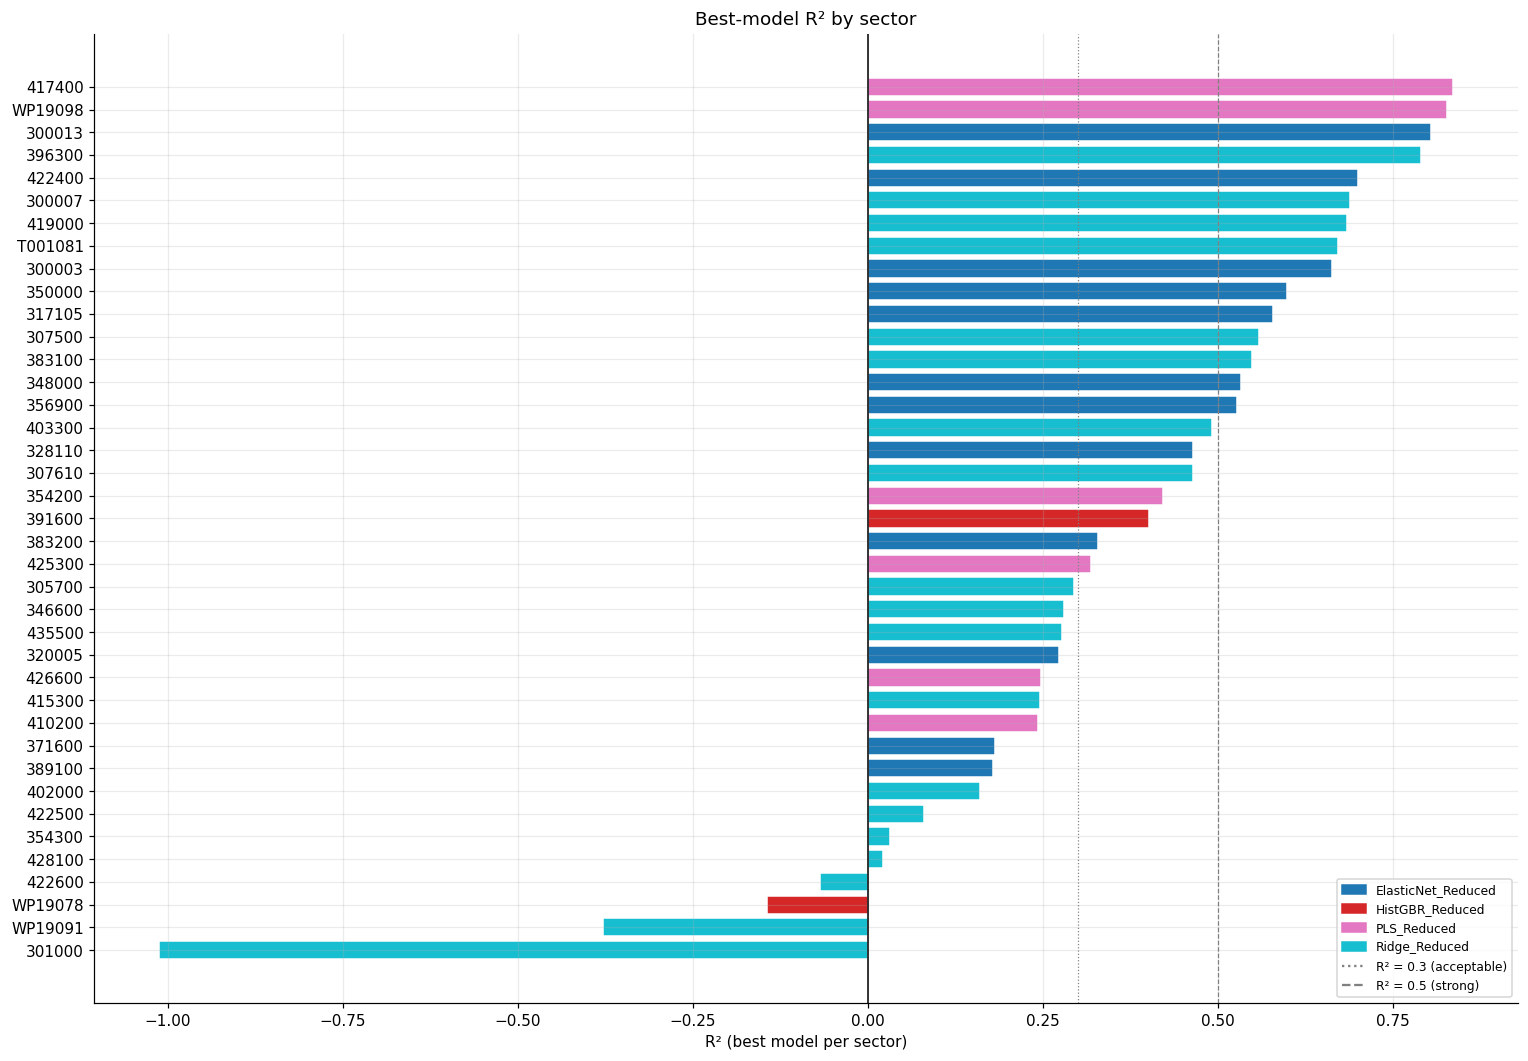

In [6]:
# Color map: stable palette per model
unique_models = sorted(summary["best_model"].unique())
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_models), 3)))
model_color = dict(zip(unique_models, palette))

fig, ax = plt.subplots(figsize=(14, max(6, len(summary) * 0.25)))
order = summary.sort_values("r2", ascending=True)
bar_colors = [model_color[m] for m in order["best_model"]]
ax.barh(order["sector"], order["r2"], color=bar_colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.3, color="grey", linestyle=":", linewidth=0.8, label="R² = 0.3 (acceptable)")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, label="R² = 0.5 (strong)")
ax.set_xlabel("R² (best model per sector)")
ax.set_title("Best-model R² by sector")
handles = [mpatches.Patch(color=model_color[m], label=m) for m in unique_models]
handles.extend([
    plt.Line2D([], [], color="grey", linestyle=":", label="R² = 0.3 (acceptable)"),
    plt.Line2D([], [], color="grey", linestyle="--", label="R² = 0.5 (strong)"),
])
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### How to read

- **Green-zone sectors** (R² > 0.5): the pipeline is doing its job. These
  are typically high-variance sectors with strong seasonal structure
  (e.g. manufacturing).
- **Yellow zone** (0.3 ≤ R² < 0.5): borderline. Usable for planning if
  the MAE is acceptable in absolute terms, but don't promise narrow
  confidence intervals.
- **Red zone** (R² < 0.3): weak. Either the sector is structurally noisy,
  the model is overfitting, or both. Always check MAE before condemning
  — low R² with low MAE just means low target variance.
- **R² < 0 bars**: never deploy. Investigate why. Plot the target series
  for these sectors before doing anything else.

The colour distribution tells you which model dominates. Ridge dominating
suggests linear effects with strong regularisation work best — consistent
with small-N training data.

## 6. Uplift — is the ML earning its keep?

Two distributions:

- **`uplift_vs_baseline`** — how much better is your best ML than the
  rolling-mean baseline? Anything ≤ 0 means the baseline wins.
- **`uplift_vs_structural`** — how much better is your best ML than a
  Ridge on five structural features? Anything ≤ 0 means the CBS feature
  engineering bought you nothing.

The metric here is the one selected in section 4 (default: MAE), expressed
as "how much lower MAE the best ML achieved". Positive = ML wins.

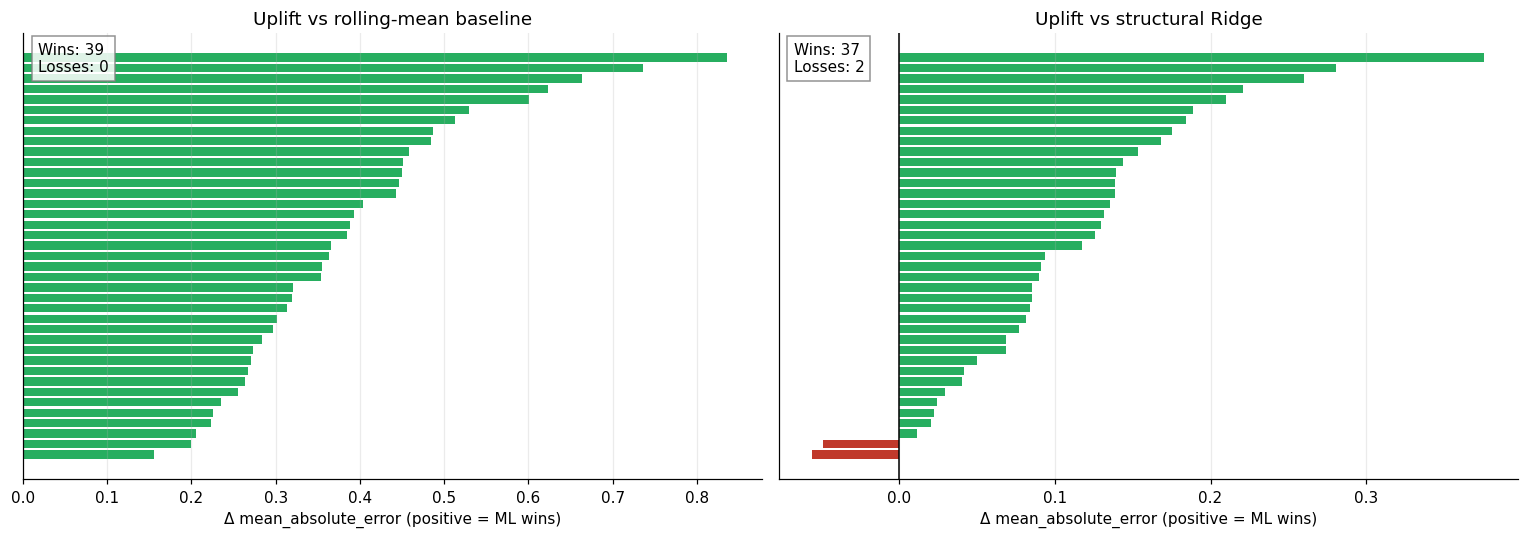

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "uplift_vs_baseline", "Uplift vs rolling-mean baseline"),
    (axes[1], "uplift_vs_structural", "Uplift vs structural Ridge"),
]:
    vals = summary[col].dropna()
    if vals.empty:
        ax.text(0.5, 0.5, f"No data for {col}\n(diagnostic didn't run)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_axis_off()
        continue
    colors = ["#c0392b" if v <= 0 else "#27ae60" for v in vals]
    ax.barh(range(len(vals)), vals.sort_values().values,
            color=[("#c0392b" if v <= 0 else "#27ae60") for v in vals.sort_values()])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(f"Δ {METRIC} (positive = ML wins)")
    ax.set_yticks([])
    n_lose = (vals <= 0).sum()
    n_win = (vals > 0).sum()
    ax.text(0.02, 0.98, f"Wins: {n_win}\nLosses: {n_lose}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="grey"))
plt.tight_layout(); plt.show()

### How to read

- **All bars green, large mean**: pipeline is delivering broadly.
- **Mixed green/red, mean near zero**: the ML works in some sectors and
  hurts in others — investigate the red ones individually.
- **Mostly green vs structural but the absolute uplift is < 0.02**:
  technically winning but the gain is within noise. The CBS features
  aren't really pulling their weight.
- **Empty plot** ("No data"): the corresponding diagnostic sweep didn't
  run. For the baseline plot specifically — re-run with
  `--only baseline` before drawing conclusions.

## 7. Regime check — pre-2023 vs post-2023

This is the structural-break test. Each point is one sector, plotted at
`(r2_pre2023, r2_post2023)`. The diagonal is "post-COVID performance equals
pre-COVID performance" — what you'd see from a model that handles the
regime change cleanly.

Points **above** the diagonal: post-COVID is better than pre-COVID
(the model improved as it saw post-COVID training data — *good*).

Points **below** the diagonal: post-COVID is worse than pre-COVID
(the regime shift hurt it — *expected, but a problem if the gap is large*).

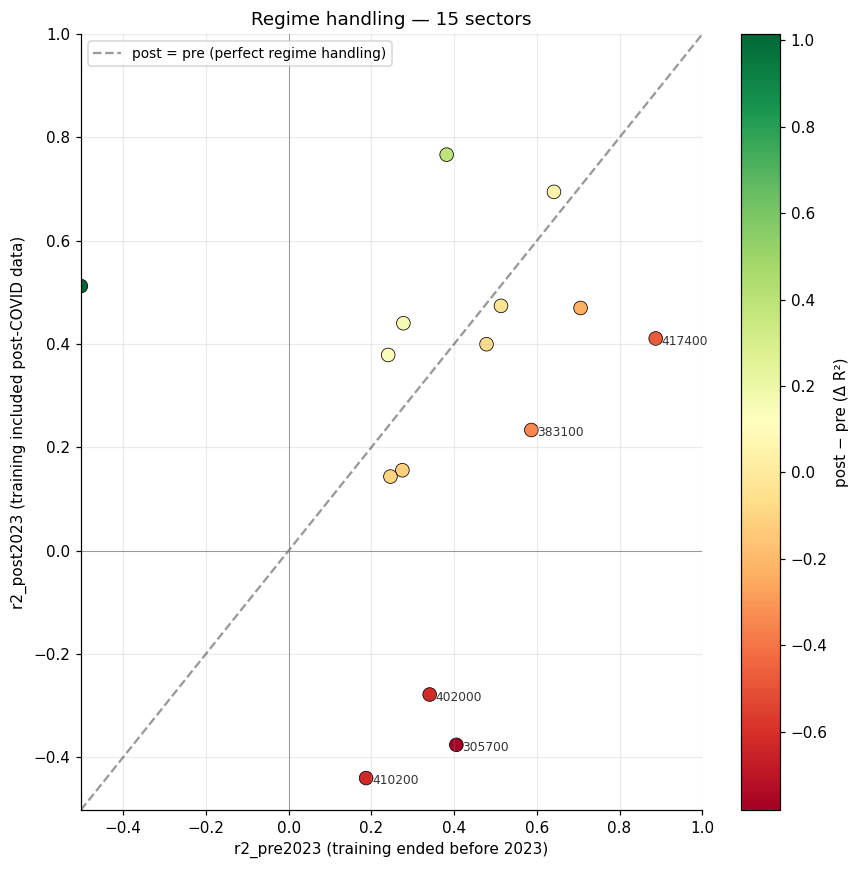


Mean r2_pre2023:   0.378
Mean r2_post2023:  0.266
Mean Δ (post-pre): -0.112
Sectors where post is worse than pre: 10/15


In [8]:
regime_df = summary.dropna(subset=["r2_pre2023", "r2_post2023"]).copy()
if regime_df.empty:
    print("No regime-split data found. (The r2_pre2023 / r2_post2023 metrics "
          "weren't logged — re-run the overnight with the regime-binning code "
          "in ml_5_model_evaluation.py.)")
else:
    fig, ax = plt.subplots(figsize=(8, 8))
    lo = min(regime_df["r2_pre2023"].min(), regime_df["r2_post2023"].min(), -0.5)
    hi = max(regime_df["r2_pre2023"].max(), regime_df["r2_post2023"].max(), 1.0)
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="post = pre (perfect regime handling)")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    sc = ax.scatter(regime_df["r2_pre2023"], regime_df["r2_post2023"],
                    c=regime_df["r2_post2023"] - regime_df["r2_pre2023"],
                    cmap="RdYlGn", s=80, edgecolor="black", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label="post − pre (Δ R²)")
    # Annotate worst regime-collapses
    worst = regime_df.assign(delta=regime_df["r2_post2023"] - regime_df["r2_pre2023"]).nsmallest(5, "delta")
    for _, r in worst.iterrows():
        ax.annotate(r["sector"], (r["r2_pre2023"], r["r2_post2023"]),
                    fontsize=8, alpha=0.8, xytext=(4, -4), textcoords="offset points")
    ax.set_xlabel("r2_pre2023 (training ended before 2023)")
    ax.set_ylabel("r2_post2023 (training included post-COVID data)")
    ax.set_title(f"Regime handling — {len(regime_df)} sectors")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    plt.tight_layout(); plt.show()

    print(f"\nMean r2_pre2023:  {regime_df['r2_pre2023'].mean(): .3f}")
    print(f"Mean r2_post2023: {regime_df['r2_post2023'].mean(): .3f}")
    print(f"Mean Δ (post-pre): {(regime_df['r2_post2023']-regime_df['r2_pre2023']).mean(): .3f}")
    n_below = ((regime_df['r2_post2023'] - regime_df['r2_pre2023']) < 0).sum()
    print(f"Sectors where post is worse than pre: {n_below}/{len(regime_df)}")

### How to read

- **Points clustered along the diagonal or above** → the regime flags
  (`covid_period`, `post_covid`) are doing their job; post-COVID
  generalises.
- **Points well below diagonal** → the model overfits the pre-COVID
  regime. The shift is structural and your flags aren't capturing it.
- **Points in lower-left quadrant (both negative)** → the sector is
  fundamentally hard. Not a regime problem, a data problem. Check the
  raw series.
- **Annotated worst sectors** → these are your highest-priority
  investigation targets. The 5 largest collapses get labels automatically.

**If the mean Δ is significantly negative** (say < -0.05), the regime
handling is inadequate across the board. Three concrete fixes, in
ascending difficulty:

1. Add a `quarters_since_covid_end` feature (continuous, not step).
2. Add interaction terms `trend_index × post_covid`, `quarter × post_covid`.
3. Apply recency sample weights so the model "forgets" pre-COVID dynamics
   that no longer apply.

## 8. Model preferences

Two views: (left) how often each model wins across sectors; (right) a
heatmap showing every model's best R² for every sector. The heatmap
reveals whether the winners win by a wide margin or just edge out runners-up.

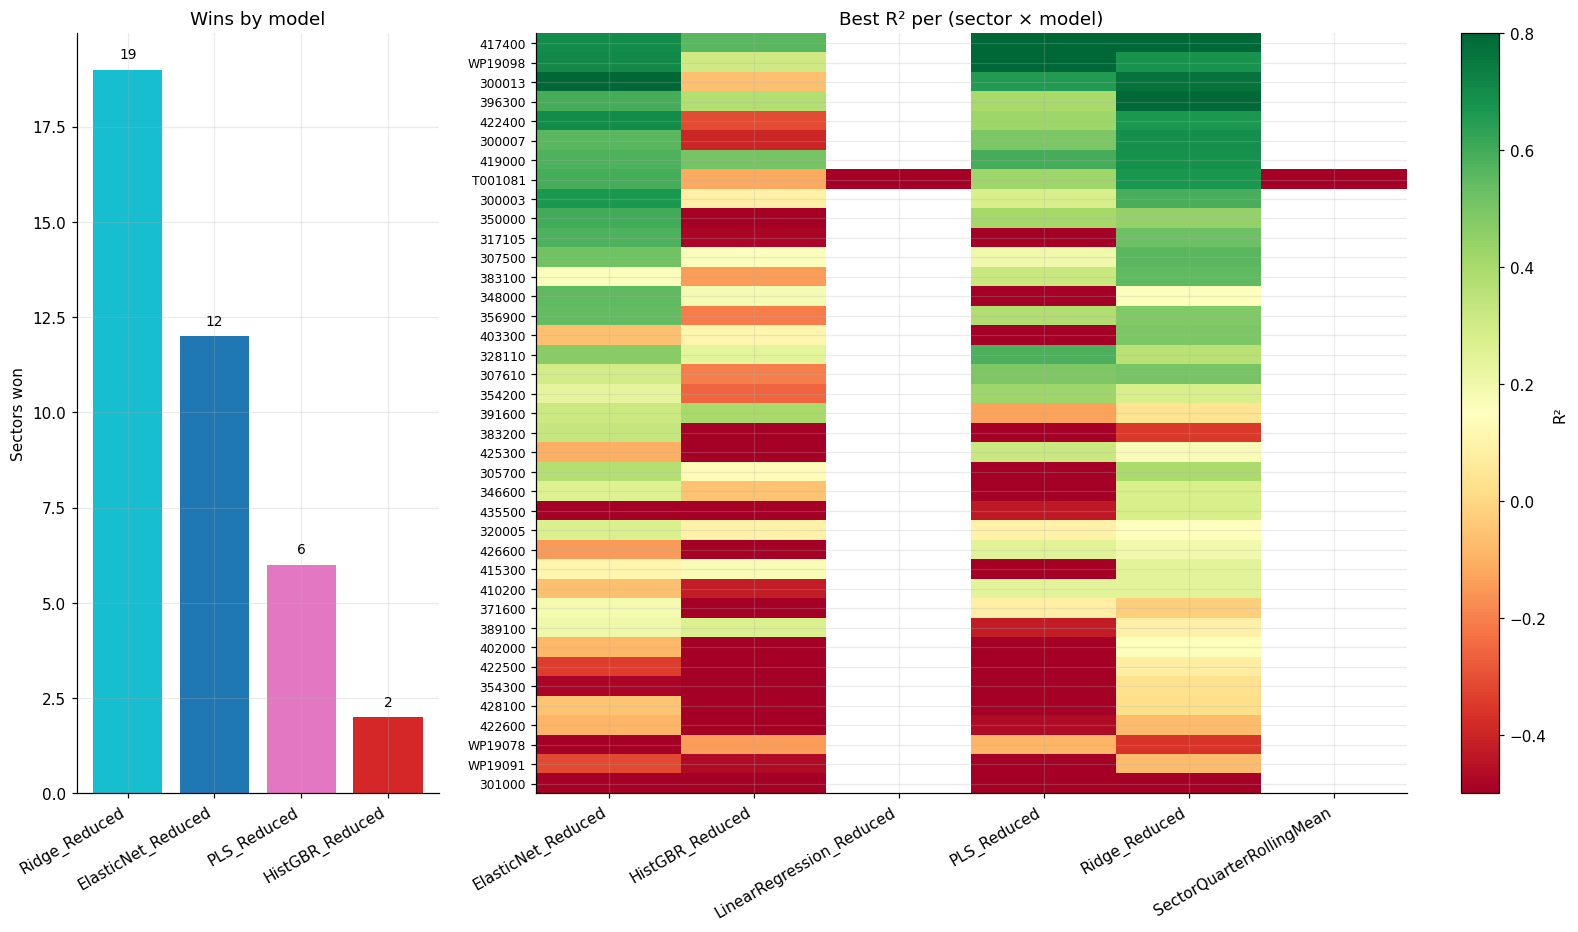

In [9]:
ml_by_sector_model = (ml.groupby(["sector", "model"])["r2_score"]
                        .max().unstack("model"))

# Order sectors by summary r2 (for visual alignment)
sector_order = summary.sort_values("r2", ascending=False)["sector"].tolist()
ml_by_sector_model = ml_by_sector_model.reindex(sector_order)

fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(sector_order) * 0.22)),
                         gridspec_kw={"width_ratios": [1, 3]})

# Left: winner counts
counts = summary["best_model"].value_counts()
axes[0].bar(range(len(counts)), counts.values,
            color=[model_color[m] for m in counts.index])
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=30, ha="right")
axes[0].set_ylabel("Sectors won")
axes[0].set_title("Wins by model")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

# Right: heatmap of best R² per (sector, model)
im = axes[1].imshow(ml_by_sector_model.values, aspect="auto",
                    cmap="RdYlGn", vmin=-0.5, vmax=0.8)
axes[1].set_xticks(range(len(ml_by_sector_model.columns)))
axes[1].set_xticklabels(ml_by_sector_model.columns, rotation=30, ha="right")
axes[1].set_yticks(range(len(ml_by_sector_model.index)))
axes[1].set_yticklabels(ml_by_sector_model.index, fontsize=8)
axes[1].set_title("Best R² per (sector × model)")
plt.colorbar(im, ax=axes[1], label="R²")
plt.tight_layout(); plt.show()

### How to read

**Winners chart.**
- One model winning > 70% of sectors: that model is doing the work; the
  others are overhead. Consider dropping them from the sweep to save time.
- Even split: the heterogeneity is real — different sectors want different
  inductive biases.

**Heatmap rows.**
- Uniform green rows: every model handles this sector well — the signal
  is strong and easy.
- Single bright green cell, others yellow: only one model captures the
  signal. Worth understanding why (probably feature interactions).
- All-red rows: this sector is genuinely hard. No model rescues it.

**Heatmap columns.**
- Vertical green stripe: that model is broadly competitive.
- Vertical red/yellow stripe: that model is uniformly worse — drop it.

## 9. Sector spotlight

For any sector you care about, the function below pulls every run for
that sector and renders a four-panel diagnostic:

1. **R² across all models** — distribution of MLflow runs for this sector
2. **Regime split** — pre vs post 2023 R² for the best model
3. **MAE across runs** — same as panel 1 but in original units
4. **Preset preference** — which preset's feature set worked best

Use this to investigate any sector flagged in the earlier plots.

In [10]:
def spotlight(sector: str):
    sub = runs_df[runs_df["sector"] == sector].copy()
    if sub.empty:
        print(f"No runs found for sector {sector!r}")
        return
    ml_sub = sub[sub["run_type"] == "ml"]
    base_sub = sub[sub["run_type"] == "baseline"]
    struct_sub = sub[sub["run_type"] == "structural"]
    row = summary[summary["sector"] == sector]
    if row.empty:
        print(f"No ML row in summary for sector {sector!r}")
        return
    row = row.iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"Sector spotlight — {sector}", fontsize=14, fontweight="bold")

    # Panel 1: R² across all ML models
    ax = axes[0, 0]
    if not ml_sub.empty:
        ml_sub_sorted = ml_sub.sort_values("r2_score")
        bars = ax.barh(
            range(len(ml_sub_sorted)),
            ml_sub_sorted["r2_score"],
            color=[model_color.get(m, "grey") for m in ml_sub_sorted["model"]],
        )
        ax.set_yticks(range(len(ml_sub_sorted)))
        ax.set_yticklabels(
            [f"{m} / {p}" for m, p in zip(ml_sub_sorted["model"], ml_sub_sorted["preset"])],
            fontsize=8,
        )
        ax.axvline(0, color="black", linewidth=1)
        if not base_sub.empty:
            ax.axvline(base_sub["r2_score"].max(), color="orange",
                       linestyle="--", label=f"baseline R² = {base_sub['r2_score'].max():.3f}")
        if not struct_sub.empty:
            ax.axvline(struct_sub["r2_score"].max(), color="purple",
                       linestyle=":", label=f"structural R² = {struct_sub['r2_score'].max():.3f}")
        ax.legend(loc="lower right", fontsize=8)
    ax.set_title("R² across all ML runs (vs. floors)")
    ax.set_xlabel("R²")

    # Panel 2: Regime split (pre vs post 2023) — best ML run only
    ax = axes[0, 1]
    pre  = row.get("r2_pre2023", np.nan)
    post = row.get("r2_post2023", np.nan)
    if not (np.isnan(pre) and np.isnan(post)):
        bars = ax.bar(["pre-2023", "post-2023"], [pre, post],
                      color=["#3498db", "#e74c3c"], edgecolor="black")
        for b, v in zip(bars, [pre, post]):
            ax.text(b.get_x() + b.get_width()/2, v + (0.02 if v>=0 else -0.04),
                    f"{v:.3f}", ha="center", fontsize=10)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_ylim(min(-0.5, pre, post) - 0.1, max(1.0, pre, post) + 0.1)
        delta = post - pre
        ax.set_title(f"Regime split (best run) — Δ = {delta:+.3f}")
    else:
        ax.text(0.5, 0.5, "No regime data\nfor this sector",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Regime split — not available")
    ax.set_ylabel("R²")

    # Panel 3: MAE across all ML runs
    ax = axes[1, 0]
    if not ml_sub.empty:
        ml_sub_sorted = ml_sub.sort_values("mean_absolute_error", ascending=True)
        ax.barh(
            range(len(ml_sub_sorted)),
            ml_sub_sorted["mean_absolute_error"],
            color=[model_color.get(m, "grey") for m in ml_sub_sorted["model"]],
        )
        ax.set_yticks(range(len(ml_sub_sorted)))
        ax.set_yticklabels(
            [f"{m} / {p}" for m, p in zip(ml_sub_sorted["model"], ml_sub_sorted["preset"])],
            fontsize=8,
        )
        if not base_sub.empty:
            ax.axvline(base_sub["mean_absolute_error"].min(), color="orange",
                       linestyle="--", label=f"baseline MAE = {base_sub['mean_absolute_error'].min():.3f}")
        if not struct_sub.empty:
            ax.axvline(struct_sub["mean_absolute_error"].min(), color="purple",
                       linestyle=":", label=f"structural MAE = {struct_sub['mean_absolute_error'].min():.3f}")
        ax.legend(loc="lower right", fontsize=8)
    ax.set_title("MAE across all ML runs (lower = better)")
    ax.set_xlabel("MAE")

    # Panel 4: Best MAE by preset
    ax = axes[1, 1]
    if not ml_sub.empty:
        preset_best = ml_sub.groupby("preset")["mean_absolute_error"].min().sort_values()
        ax.barh(range(len(preset_best)), preset_best.values,
                color="#34495e", edgecolor="white")
        ax.set_yticks(range(len(preset_best)))
        ax.set_yticklabels(preset_best.index, fontsize=9)
        ax.set_xlabel("Best MAE achieved (any model)")
        ax.set_title("Preset preference for this sector")

    plt.tight_layout()
    plt.show()

    # Print compact summary
    print(f"=== {sector} ===")
    print(f"Best model        : {row['best_model']}  /  preset = {row['best_preset']}")
    print(f"R²                : {row['r2']:.3f}")
    print(f"MAE               : {row['mae']:.3f}  (≈ {row['mae']/0.045*100:.1f}% of a 4.5%-sick-leave baseline)")
    print(f"r2_pre2023        : {row.get('r2_pre2023', np.nan):.3f}")
    print(f"r2_post2023       : {row.get('r2_post2023', np.nan):.3f}")
    print(f"Uplift vs baseline    : {row['uplift_vs_baseline']:+.3f}"
          if pd.notna(row['uplift_vs_baseline']) else "Uplift vs baseline    : (no baseline run)")
    print(f"Uplift vs structural  : {row['uplift_vs_structural']:+.3f}"
          if pd.notna(row['uplift_vs_structural']) else "Uplift vs structural  : (no structural run)")

### Example: spotlight the best-performing sector

The sector with the highest `r2`. Use this as the reference for what
"working well" looks like — strong R², modest gap between pre and
post 2023, multiple models clustered near the top.

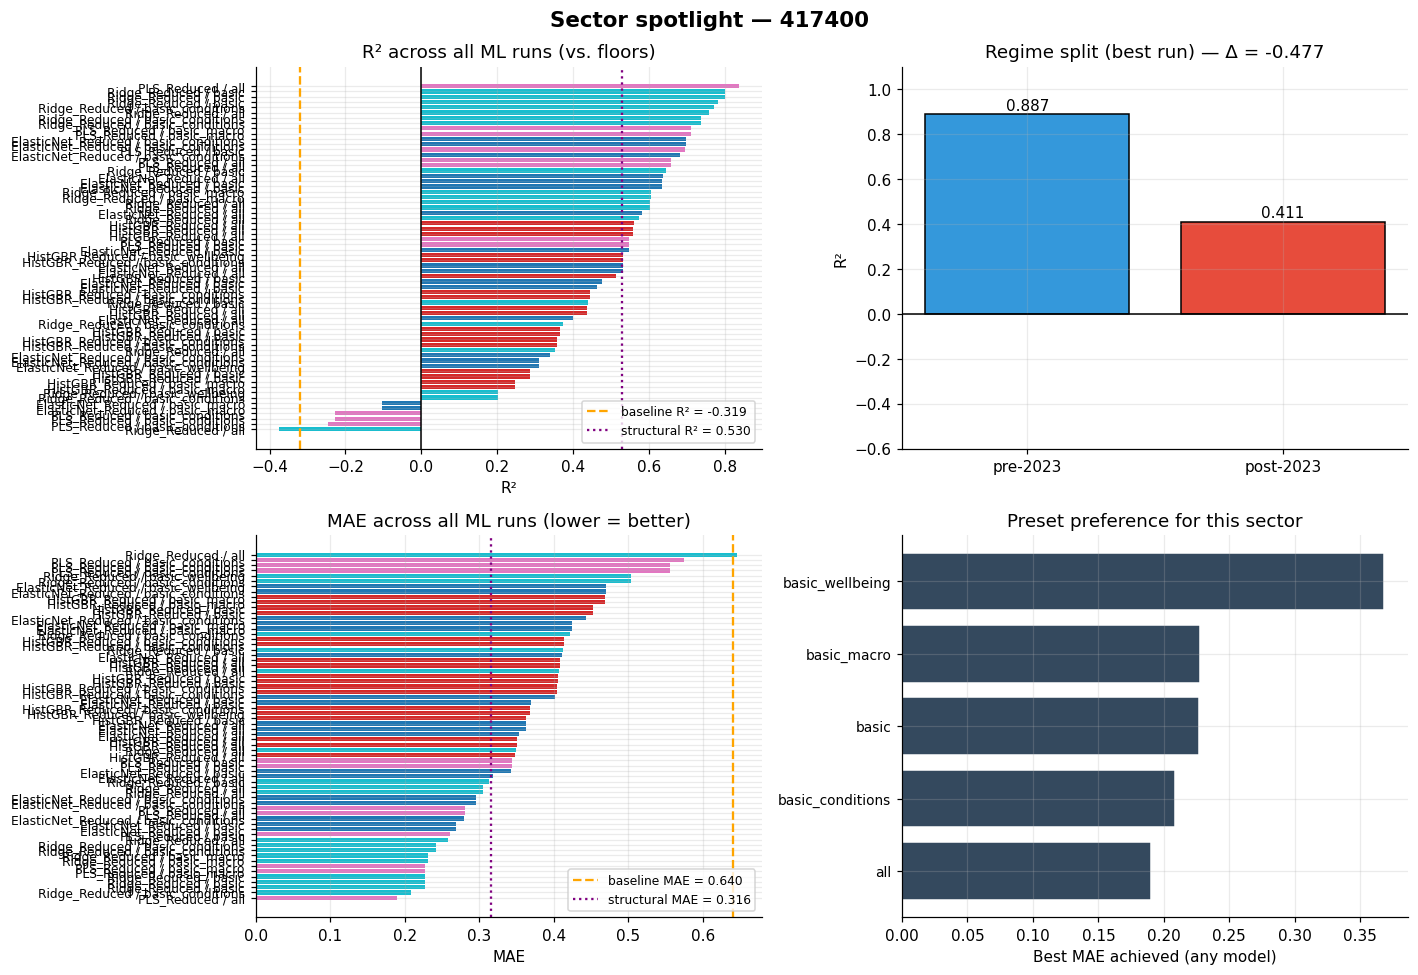

=== 417400 ===
Best model        : PLS_Reduced  /  preset = all
R²                : 0.837
MAE               : 0.190  (≈ 422.8% of a 4.5%-sick-leave baseline)
r2_pre2023        : 0.887
r2_post2023       : 0.411
Uplift vs baseline    : +0.450
Uplift vs structural  : +0.126


In [11]:
best_sector = summary.iloc[0]["sector"]
spotlight(best_sector)

### Example: spotlight the worst-performing sector

The sector with the lowest `r2`. Likely to be one of the negative-R²
cases — useful as a contrast to the success above. Look for:

- All models clustered at similar (poor) R² → sector-level data problem
- One bright outlier → maybe overfit, maybe a real find
- Huge pre-vs-post gap → regime-collapse case

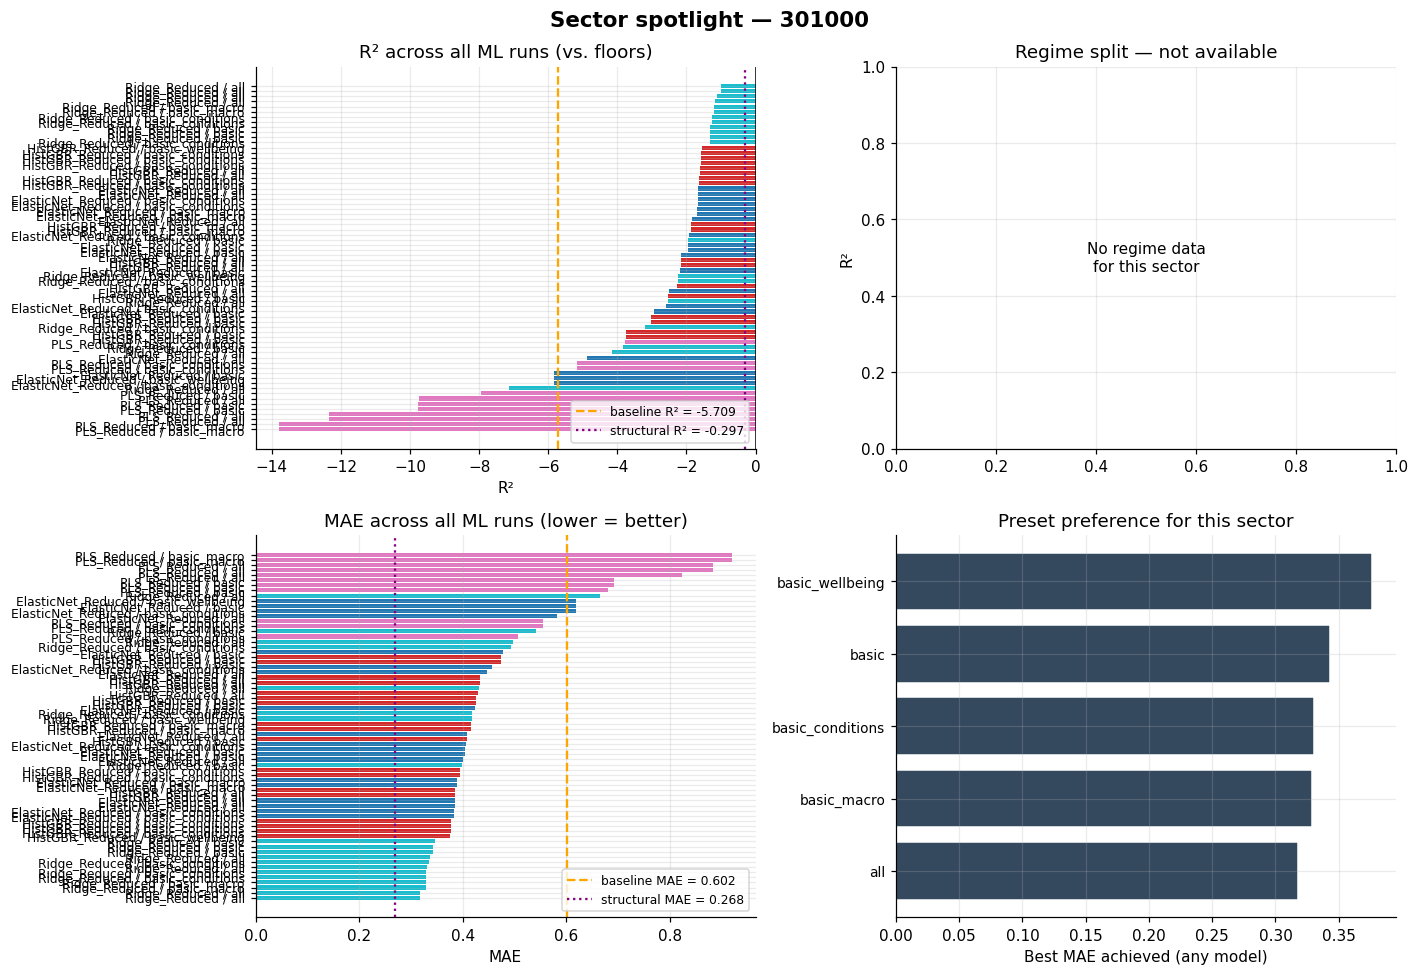

=== 301000 ===
Best model        : Ridge_Reduced  /  preset = all
R²                : -1.013
MAE               : 0.318  (≈ 706.4% of a 4.5%-sick-leave baseline)
r2_pre2023        : nan
r2_post2023       : nan
Uplift vs baseline    : +0.284
Uplift vs structural  : -0.049


In [12]:
worst_sector = summary.iloc[-1]["sector"]
spotlight(worst_sector)

### Spotlight any sector you want

Set `target_sector` below and re-run the cell.

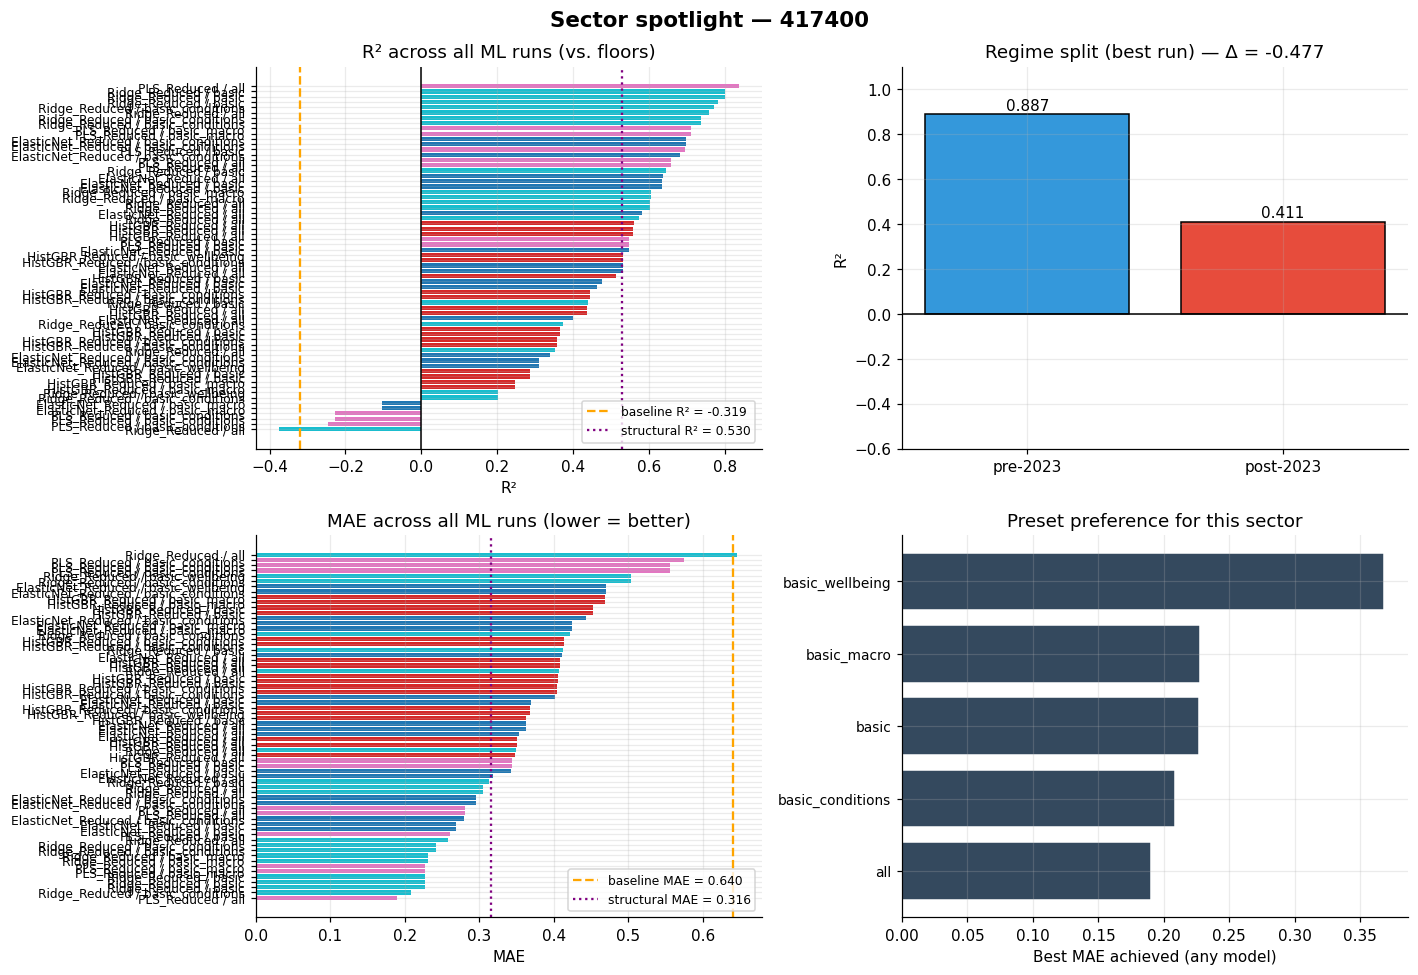

=== 417400 ===
Best model        : PLS_Reduced  /  preset = all
R²                : 0.837
MAE               : 0.190  (≈ 422.8% of a 4.5%-sick-leave baseline)
r2_pre2023        : 0.887
r2_post2023       : 0.411
Uplift vs baseline    : +0.450
Uplift vs structural  : +0.126


In [13]:
# Change this to investigate a specific sector
target_sector = best_sector  # e.g. "301000", "T001081", "WP19078"
spotlight(target_sector)

## 10. Auto-flagged concerns

The cell below classifies every sector into one of four diagnostic
buckets, based on the metrics in section 4. Read this as a triage list:

| Bucket | Meaning | Action |
|---|---|---|
| 🟢 Healthy | R² ≥ 0.3 and regime gap < 0.2 | Keep |
| 🟡 Borderline | 0.1 ≤ R² < 0.3 OR regime gap 0.2–0.4 | Watch |
| 🔴 Regime-broken | R² ≥ 0.3 pre, but R² < 0 post (or large gap) | Fix regime handling |
| ⛔ Failing | R² < 0 or beaten by baseline | Investigate / drop |


In [14]:
def classify(row):
    r2 = row.get("r2", np.nan)
    pre  = row.get("r2_pre2023", np.nan)
    post = row.get("r2_post2023", np.nan)
    uplift_baseline = row.get("uplift_vs_baseline", np.nan)

    if pd.notna(uplift_baseline) and uplift_baseline <= 0:
        return "⛔ Failing — baseline wins"
    if pd.notna(r2) and r2 < 0:
        return "⛔ Failing — negative R²"
    if pd.notna(pre) and pd.notna(post) and pre > 0.3 and post < 0:
        return "🔴 Regime-broken"
    if pd.notna(pre) and pd.notna(post) and (pre - post) > 0.4:
        return "🔴 Large regime gap"
    if pd.notna(r2) and r2 < 0.1:
        return "🟡 Borderline — low R²"
    if pd.notna(pre) and pd.notna(post) and (pre - post) > 0.2:
        return "🟡 Borderline — moderate regime gap"
    if pd.notna(r2) and r2 < 0.3:
        return "🟡 Borderline"
    return "🟢 Healthy"

summary["status"] = summary.apply(classify, axis=1)
status_counts = summary["status"].value_counts()
print("Status distribution:")
for s, n in status_counts.items():
    print(f"  {s:35s} {n:3d}")

print("\nSectors needing attention (sorted by severity):")
# order_map = {"⛔": 0, "🔴": 1, "🟡": 2, "🟢": 3}
order_map = {"🟢": 0, "🟡": 1, "🔴": 2, "⛔": 3}
concerning = summary[summary["status"].str.contains("⛔|🔴|🟡|🟢", regex=True)].copy()
concerning["_o"] = concerning["status"].str[0].map(order_map)
concerning = concerning.sort_values(["_o", "r2"]).drop(columns="_o")
concerning[["sector", "best_model", "best_preset", "r2",
            "r2_pre2023", "r2_post2023",
            "uplift_vs_baseline", "uplift_vs_structural", "status"]]

Status distribution:
  🟢 Healthy                            19
  🟡 Borderline                          7
  ⛔ Failing — negative R²               4
  🟡 Borderline — low R²                 3
  🔴 Large regime gap                    2
  🟡 Borderline — moderate regime gap    2
  🔴 Regime-broken                       2

Sectors needing attention (sorted by severity):


,sector,best_model,best_preset,r2,r2_pre2023,r2_post2023,uplift_vs_baseline,uplift_vs_structural,status
21,425300,PLS_Reduced,all,0.319134,NaN,NaN,0.663766,0.175201,🟢 Healthy
20,383200,ElasticNet_Reduced,basic,0.329632,NaN,NaN,0.487110,0.083926,🟢 Healthy
19,391600,HistGBR_Reduced,all,0.402172,NaN,NaN,0.273307,0.022222,🟢 Healthy
18,354200,PLS_Reduced,basic_conditions,0.421961,NaN,NaN,0.365129,0.188939,🟢 Healthy
17,307610,Ridge_Reduced,all,0.464762,0.478407,0.399602,0.354105,0.209655,🟢 Healthy
16,328110,ElasticNet_Reduced,basic_conditions,0.465161,0.382014,0.766689,0.320899,0.143977,🟢 Healthy
15,403300,Ridge_Reduced,basic_conditions,0.492537,NaN,NaN,0.204781,0.081340,🟢 Healthy
14,356900,ElasticNet_Reduced,basic_conditions,0.526977,NaN,NaN,0.312952,0.091260,🟢 Healthy
13,348000,ElasticNet_Reduced,basic_macro,0.533249,NaN,NaN,0.296601,-0.055983,🟢 Healthy
11,307500,Ridge_Reduced,basic_conditions,0.558893,NaN,NaN,0.199179,0.085297,🟢 Healthy


## 11. Reading the whole notebook

After running everything, walk through these four questions in order:

**Q1. Did the baseline run?** *(Section 3)*
- No → re-run with `--only baseline`. Stop. The rest is undefined until
  this is done.
- Yes → continue.

**Q2. How many sectors beat the baseline?** *(Section 6, left plot)*
- < 50% → the ML isn't a broad win. Maybe useful for specific sectors,
  but you shouldn't be promoting it as a general pipeline.
- 50-80% → typical. The ML helps for most sectors but has clear losers
  worth investigating.
- > 80% → strong overall result.

**Q3. Is the regime collapse uniform or sector-specific?** *(Sections 7, 10)*
- Mean Δ(post − pre) > -0.05 → the flags are working well enough. Leave it.
- Mean Δ between -0.05 and -0.15 → moderate. Try the `quarters_since_covid_end`
  feature (cheap fix).
- Mean Δ < -0.15 → systematic. The flag-based regime handling isn't enough.
  Move to interaction terms or recency weighting.

**Q4. What does the auto-flag table say?** *(Section 10)*
- Mostly 🟢 → ship it for production-relevant sectors.
- Many 🟡 → useful for direction but communicate the uncertainty to consumers.
- Many 🔴/⛔ → you have systematic issues. Don't aggregate up to a
  headline R² and call it a day — that hides the heterogeneity.

The point isn't to land on a single "is it good?" answer. It's to know
**which sectors the model serves well, which it serves poorly, and why**.
That's the operational answer your downstream consumers actually need.